# Question 2 — Shots On Target

Is the average number of shots on target per match significantly different from 8 in the FIFA World Cup 2026?

**Objective 1.** Run the cells from top to bottom. This notebook loads the original CSV independently. Tables and graphs appear directly beneath their code cells.

## 1. Libraries and project paths
Use the project `.venv` kernel. Inline plotting keeps the figures inside this notebook.

In [1]:
# Display graphs directly below their notebook cells.
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

QUESTION = 'Is the average number of shots on target per match significantly different from 8 in the FIFA World Cup 2026?'
NUMBER = 2
# Locate the project whether this notebook starts in the root or its question folder.
ROOT = Path.cwd()
if not (ROOT / 'data').is_dir():
    ROOT = ROOT.parent
BASE = ROOT / 'Question_2_Shots_On_Target'
for directory in ['processed_data', 'figures', 'tables', 'results']:
    (BASE / directory).mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 35)
print(QUESTION)

Is the average number of shots on target per match significantly different from 8 in the FIFA World Cup 2026?


## 2. Load and inspect the raw CSV
The file has 28 columns and repeated stage/header rows. We inspect these before selecting match observations.

In [2]:
path = ROOT / 'data' / 'World Cup - 2026 - Stats - Fixtures.csv'
# Keep every row initially because this CSV contains several header rows.
raw = pd.read_csv(path, header=None)
# Read the third row as column labels for inspection only; no match data are loaded here.
headers = pd.read_csv(path, header=2, nrows=0).columns.tolist()
print('Raw rows:', len(raw), '| Columns:', raw.shape[1])
display(raw.head())

Raw rows: 121 | Columns: 28


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,GROUP STAGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,GOALS,NaN,NaN,NaN,CARDS,NaN,NaN,NaN,CORNERS,NaN,NaN,NaN,NaN,NaN,NaN,xG,NaN,SHOTS,NaN,SHOTS ON\nTARGET,NaN,FOULS,NaN
2,Date,Team 1,Result,NaN,Team 2,1H,NaN,2H,NaN,YEL,NaN,RED,NaN,1H C,NaN,2H C,NaN,MC,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11/6/2026,Mexico,2,0,South Africa,1,0.0,1,0.0,1,2.0,1,2.0,2,1.0,1,0.0,3,1.0,4,1.46,0.07,16,3.0,4,2.0,12,11.0
4,12/6/2026,South Korea,2,1,Czech Republic,0,0.0,2,1.0,1,0.0,0,0.0,3,3.0,1,2.0,4,5.0,9,2.3,0.83,15,7.0,6,4.0,9,16.0


In [3]:
# Combine column names, types and missing counts into one readable inspection table.
column_inspection = pd.DataFrame({
    'Position': range(raw.shape[1]),
    'Original pandas name (header=2)': headers,
    'Raw data type': raw.dtypes.astype(str).values,
    'Missing values': raw.isnull().sum().values
})
display(column_inspection)
print('Raw duplicate records (including repeated headers):', raw.duplicated().sum())

,Position,Original pandas name (header=2),Raw data type,Missing values
0,0,Date,str,6
1,1,Team 1,str,12
2,2,Result,str,12
3,3,Unnamed: 3,str,18
4,4,Team 2,str,12
5,5,1H,str,6
6,6,Unnamed: 6,float64,18
7,7,2H,str,12
8,8,Unnamed: 8,float64,18
9,9,YEL,str,6


Raw duplicate records (including repeated headers): 9


## 3. Extract match rows and identify stages
Stage labels are section headings. Carry them down to their matches and remove the repeated headers. No merge is required.

In [4]:
stages = ['GROUP STAGE', 'ROUND OF 32', 'ROUND OF 16',
          'QUARTER FINALS', 'SEMI FINALS', 'FINAL']
if raw.shape[1] != 28 or raw.iloc[2, 2] != 'Result' or raw.iloc[2, 17] != 'MC':
    raise ValueError('CSV layout changed: inspect its headers before analysing.')
# Keep recognised stage headings, then carry each heading down to its match rows.
raw['Stage'] = raw[0].where(raw[0].isin(stages)).ffill()
# A date-shaped first field identifies a match rather than a repeated header.
match_rows = raw[0].astype('str').str.fullmatch(r'\d{1,2}/\d{1,2}/\d{4}', na=False)
matches = raw.loc[match_rows].copy()

print('Match observations:', len(matches))
display(matches.head())
display(matches['Stage'].value_counts().rename('Matches').to_frame())

Match observations: 103


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,Stage
3,11/6/2026,Mexico,2,0,South Africa,1,0.0,1,0.0,1,2.0,1,2.0,2,1.0,1,0.0,3,1.0,4,1.46,0.07,16,3.0,4,2.0,12,11.0,GROUP STAGE
4,12/6/2026,South Korea,2,1,Czech Republic,0,0.0,2,1.0,1,0.0,0,0.0,3,3.0,1,2.0,4,5.0,9,2.3,0.83,15,7.0,6,4.0,9,16.0,GROUP STAGE
5,12/6/2026,Canada,1,1,Bosnia & Herzegovina,0,1.0,1,0.0,2,3.0,0,0.0,9,1.0,0,3.0,9,4.0,13,1.25,0.98,13,8.0,4,3.0,10,20.0,GROUP STAGE
6,13/6/2026,USA,4,1,Paraguay,3,0.0,1,1.0,1,5.0,0,0.0,2,0.0,1,1.0,3,1.0,4,1.42,0.54,16,9.0,6,1.0,13,17.0,GROUP STAGE
7,13/6/2026,Qatar,1,1,Switzerland,0,1.0,1,0.0,2,1.0,0,0.0,3,4.0,0,6.0,3,10.0,13,0.6,3.20,6,26.0,3,7.0,12,11.0,GROUP STAGE


,Matches
Stage,
GROUP STAGE,72
ROUND OF 32,16
ROUND OF 16,8
QUARTER FINALS,4
SEMI FINALS,2
FINAL,1


## 4. Select the relevant columns
The aliases below are explicitly mapped to the inspected CSV positions. Scores use `Result` and its unnamed neighbour; corners use `MC` and its neighbour; yellow cards use `YEL` and its neighbour; target shots use the pair beneath `SHOTS ON\nTARGET`.

In [5]:
# Map verified zero-based CSV positions to readable names for this question.
mapping = {0: 'Date', 1: 'Team 1', 4: 'Team 2', 24: 'Target 1', 25: 'Target 2'}
data = matches[list(mapping) + ['Stage']].rename(columns=mapping).copy()
# Keep the original CSV record number so each selected match can be traced back.
data['Source record'] = data.index + 1
display(data.head(10))
display(pd.DataFrame({'Type': data.dtypes.astype(str), 'Missing': data.isnull().sum()}))

,Date,Team 1,Team 2,Target 1,Target 2,Stage,Source record
3,11/6/2026,Mexico,South Africa,4,2.0,GROUP STAGE,4
4,12/6/2026,South Korea,Czech Republic,6,4.0,GROUP STAGE,5
5,12/6/2026,Canada,Bosnia & Herzegovina,4,3.0,GROUP STAGE,6
6,13/6/2026,USA,Paraguay,6,1.0,GROUP STAGE,7
7,13/6/2026,Qatar,Switzerland,3,7.0,GROUP STAGE,8
8,13/6/2026,Brazil,Morocco,5,3.0,GROUP STAGE,9
9,14/6/2026,Haiti,Scotland,2,2.0,GROUP STAGE,10
10,14/6/2026,Australia,Turkey,4,8.0,GROUP STAGE,11
11,14/6/2026,Germany,Curacao,12,2.0,GROUP STAGE,12
12,14/6/2026,Netherlands,Japan,6,3.0,GROUP STAGE,13


,Type,Missing
Date,str,0
Team 1,str,0
Team 2,str,0
Target 1,str,0
Target 2,float64,0
Stage,str,0
Source record,int64,0


## 5. Clean required fields
Check duplicates, dates, missing values and nonnegative integer counts. Only the fields required for this question determine eligibility. Numeric scores retain the number from `p0` or `1p`; shootout kicks are never added to goals.

In [6]:
before = len(data)
# Only exact duplicate match records are removed. Conflicting identities stop the run.
exact_duplicates = matches.drop(columns='Stage').duplicated()
data = data.loc[~exact_duplicates].copy()
print('Exact duplicate matches removed: %d' % exact_duplicates.sum())
if data.duplicated(['Date', 'Team 1', 'Team 2']).any():
    raise ValueError('Conflicting duplicate match identities need review.')
# Parse day/month/year dates; errors="coerce" marks unparseable values as missing.
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y', errors='coerce')
# Remove extra spaces from team names and treat empty names as missing.
for column in ['Team 1', 'Team 2']:
    data[column] = data[column].str.strip().replace('', pd.NA)
numeric_columns = ['Target 1', 'Target 2']
for column in numeric_columns:
    values = data[column].astype('str')
    if column.startswith('Score'):
        # Only accept a numeric score with an optional leading/trailing p marker.
        # Retain the numeric match score, never add shootout kicks to goals.
        valid_score = values.str.fullmatch(r'(?:p\d+|\d+p?)', na=False)
        values = values.where(valid_score).str.replace('p', '', regex=False)
    data[column] = pd.to_numeric(values, errors='coerce')
# Flag a row if any required count is missing, infinite, negative or fractional.
invalid_numeric = (~np.isfinite(data[numeric_columns]) |
                   (data[numeric_columns] < 0) |
                   (data[numeric_columns] % 1 != 0)).any(axis=1)
# Check only the fields needed for this analysis, not every field in the original CSV.
missing_required = data[list(mapping.values()) + ['Stage']].isnull().any(axis=1)
print('Missing/unparseable required fields: %d' % missing_required.sum())
print('Rows with invalid, negative or noninteger counts: %d' % invalid_numeric.sum())

print('Rows excluded for invalid or missing required fields:')
display(data.loc[missing_required | invalid_numeric])
# The ~ symbol means NOT: keep rows that pass both cleaning checks.
data = data.loc[~(missing_required | invalid_numeric)].copy()
display(data.head(10))

Exact duplicate matches removed: 0
Missing/unparseable required fields: 0
Rows with invalid, negative or noninteger counts: 0
Rows excluded for invalid or missing required fields:


,Date,Team 1,Team 2,Target 1,Target 2,Stage,Source record


,Date,Team 1,Team 2,Target 1,Target 2,Stage,Source record
3,2026-06-11,Mexico,South Africa,4,2.0,GROUP STAGE,4
4,2026-06-12,South Korea,Czech Republic,6,4.0,GROUP STAGE,5
5,2026-06-12,Canada,Bosnia & Herzegovina,4,3.0,GROUP STAGE,6
6,2026-06-13,USA,Paraguay,6,1.0,GROUP STAGE,7
7,2026-06-13,Qatar,Switzerland,3,7.0,GROUP STAGE,8
8,2026-06-13,Brazil,Morocco,5,3.0,GROUP STAGE,9
9,2026-06-14,Haiti,Scotland,2,2.0,GROUP STAGE,10
10,2026-06-14,Australia,Turkey,4,8.0,GROUP STAGE,11
11,2026-06-14,Germany,Curacao,12,2.0,GROUP STAGE,12
12,2026-06-14,Netherlands,Japan,6,3.0,GROUP STAGE,13


## 6. Construct the analysis variable and eligible population
The benchmark of 8 applies to the sum of BOTH teams’ shots on target.

In [7]:
# Feature engineering: add both teams’ target shots; the benchmark 8 refers to this total.
data['Total Shots on Target Per Match'] = data['Target 1'] + data['Target 2']
print('Benchmark 8 means TOTAL shots on target for BOTH teams per match.')
variables = ['Total Shots on Target Per Match']
population_description = 'All supplied matches with valid shots-on-target information.'
print('Rows before cleaning: %d\nRows removed: %d\nRows after cleaning / eligible population: %d' %
       (before, before - len(data), len(data)))
print('Prepared data types:\n' + data.dtypes.to_string())
data.to_csv(BASE / 'processed_data' / ('question%d_population.csv' % NUMBER), index=False)
# Show every eligible observation, not just its dimensions.
with pd.option_context('display.max_rows', None):
    display(data)

Benchmark 8 means TOTAL shots on target for BOTH teams per match.
Rows before cleaning: 103
Rows removed: 0
Rows after cleaning / eligible population: 103
Prepared data types:
Date                               datetime64[us]
Team 1                                        str
Team 2                                        str
Target 1                                    int64
Target 2                                  float64
Stage                                         str
Source record                               int64
Total Shots on Target Per Match           float64


,Date,Team 1,Team 2,Target 1,Target 2,Stage,Source record,Total Shots on Target Per Match
3,2026-06-11,Mexico,South Africa,4,2.0,GROUP STAGE,4,6.0
4,2026-06-12,South Korea,Czech Republic,6,4.0,GROUP STAGE,5,10.0
5,2026-06-12,Canada,Bosnia & Herzegovina,4,3.0,GROUP STAGE,6,7.0
6,2026-06-13,USA,Paraguay,6,1.0,GROUP STAGE,7,7.0
7,2026-06-13,Qatar,Switzerland,3,7.0,GROUP STAGE,8,10.0
8,2026-06-13,Brazil,Morocco,5,3.0,GROUP STAGE,9,8.0
9,2026-06-14,Haiti,Scotland,2,2.0,GROUP STAGE,10,4.0
10,2026-06-14,Australia,Turkey,4,8.0,GROUP STAGE,11,12.0
11,2026-06-14,Germany,Curacao,12,2.0,GROUP STAGE,12,14.0
12,2026-06-14,Netherlands,Japan,6,3.0,GROUP STAGE,13,9.0


## 7. Simple random sampling — 40 matches
Week 4 teaches checking that observations were obtained by simple random sampling. After cleaning, draw exactly 40 eligible matches without replacement, with `random_state=42` for reproducibility. Every eligible match has the same chance of selection. The sample size of 40 is specified for this project; it is not a class rule or a power calculation.

The sampling unit is one match. For winner–loser comparisons, both teams remain together in the sampled match.

In [8]:
# Simple random sampling, as discussed in the Week 4 inference lesson.
SAMPLE_SIZE = 40
print('Population:', population_description)
print('Population size:', len(data))
print('Sampling method: simple random sampling without replacement')
print('Random state: 42')
if len(data) < SAMPLE_SIZE:
    raise ValueError('Fewer than 40 eligible matches are available.')
# Select 40 distinct matches fairly; seed 42 reproduces the same selection on the same data.
sample = data.sample(n=SAMPLE_SIZE, replace=False, random_state=42)
print('Sample size:', len(sample))

series_to_describe = {column: sample[column] for column in variables}

sample.to_csv(BASE / 'processed_data' / f'question{NUMBER}_sample.csv', index=False)
print('Actual sampled data used below:')
with pd.option_context('display.max_rows', None):
    display(sample)

Population: All supplied matches with valid shots-on-target information.
Population size: 103
Sampling method: simple random sampling without replacement
Random state: 42
Sample size: 40
Actual sampled data used below:


,Date,Team 1,Team 2,Target 1,Target 2,Stage,Source record,Total Shots on Target Per Match
33,2026-06-20,Brazil,Haiti,5,3.0,GROUP STAGE,34,8.0
70,2026-06-27,Panama,England,2,6.0,GROUP STAGE,71,8.0
65,2026-06-27,Cape Verde,Saudi Arabia,2,3.0,GROUP STAGE,66,5.0
50,2026-06-24,Colombia,D.R. Congo,9,1.0,GROUP STAGE,51,10.0
45,2026-06-23,Norway,Senegal,7,4.0,GROUP STAGE,46,11.0
43,2026-06-22,Argentina,Austria,5,1.0,GROUP STAGE,44,6.0
99,2026-07-05,Brazil,Norway,4,5.0,ROUND OF 16,100,9.0
48,2026-06-23,England,Ghana,3,1.0,GROUP STAGE,49,4.0
13,2026-06-15,Ivory Coast,Ecuador,4,1.0,GROUP STAGE,14,5.0
3,2026-06-11,Mexico,South Africa,4,2.0,GROUP STAGE,4,6.0


## 8. Descriptive statistics and outlier inspection
Sample standard deviation and variance use `ddof=1`. IQR flags are reported for inspection; no observation is removed just because it is extreme.

In [9]:
# Calculate the same descriptive measures for each sample variable or stage group.
summaries = {}
for name, series in series_to_describe.items():
    # Q1 and Q3 mark the 25th and 75th percentiles; their difference is the IQR.
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    # ddof=1 uses n−1 in sample variance; standard deviation is its square root.
    summaries[name] = {'count': series.count(), 'mean': series.mean(),
        'median': series.median(), 'sample std': series.std(ddof=1),
        'sample variance': series.var(ddof=1), 'min': series.min(),
        'max': series.max(), 'Q1': q1, 'Q3': q3, 'IQR': q3 - q1}
    # Flag values outside the usual 1.5 × IQR limits for inspection, but retain them.
    outliers = series[(series < q1 - 1.5 * (q3-q1)) | (series > q3 + 1.5 * (q3-q1))]
    print('IQR-flagged observations for %s (retained): %s' % (name, outliers.tolist()))
# Transpose with .T so each analysed variable becomes a table row.
summary = pd.DataFrame(summaries).T
display(summary.round(4))
summary.to_csv(BASE / 'tables' / ('question%d_descriptive_statistics.csv' % NUMBER))

IQR-flagged observations for Total Shots on Target Per Match (retained): []


,count,mean,median,sample std,sample variance,min,max,Q1,Q3,IQR
Total Shots on Target Per Match,40.0,7.85,8.0,2.4237,5.8744,4.0,12.0,6.0,9.25,3.25


## 9. Confidence interval
Use the t distribution because the population standard deviation is unknown. The calculation below shows the mean, standard error, critical value and interval bounds.

In [10]:
# Select the tested variable: the match total in Q2 or the within-match difference in Q3–4.
values = sample[variables[-1]]
n = len(values)
mean = np.mean(values)
sample_std = np.std(values, ddof=1)
# Standard error measures uncertainty in the estimated mean, not variation among individual matches.
standard_error = sample_std / np.sqrt(n)
# Estimating one sample mean leaves n−1 degrees of freedom for this t calculation.
degrees_freedom = n - 1
print('Sample mean: %.4f\nSample standard deviation: %.4f\nSample size: %d' % (mean, sample_std, n))
# This is the population mean claimed under H0: 8 total target shots, or a zero difference.
benchmark = 8
h0 = 'mu_total_shots_on_target = 8'
h1 = 'mu_total_shots_on_target != 8'

Sample mean: 7.8500
Sample standard deviation: 2.4237
Sample size: 40


In [11]:
if not np.isfinite(standard_error) or standard_error <= 0:
    raise ValueError('A nonzero finite standard error is required for these t procedures.')
# A two-sided 95% interval leaves 2.5% in each tail, so use the 0.975 t quantile.
t_critical = st.t.ppf(0.975, df=degrees_freedom)
# Multiply the critical value by the standard error; add/subtract this margin around the estimate.
margin_error = t_critical * standard_error
ci_lower = mean - margin_error
ci_upper = mean + margin_error
print('\n95%% CONFIDENCE INTERVAL\nEstimate: %.4f\nStandard error: %.4f\nDegrees of freedom: %.4f\nt critical: %.4f\nMargin of error: %.4f\n95%% CI lower: %.4f\n95%% CI upper: %.4f' %
       (mean, standard_error, degrees_freedom, t_critical, margin_error, ci_lower, ci_upper))
print('Under the t-model assumptions, the interval estimates the population mean of the analysed variable or mean difference. It is not an interval for individual matches.')
ci_table = pd.DataFrame([{'Estimate': mean, 'Standard error': standard_error,
    'Degrees of freedom': degrees_freedom, 't critical': t_critical,
    'Lower 95% CI': ci_lower, 'Upper 95% CI': ci_upper}])
display(ci_table.round(4))


95% CONFIDENCE INTERVAL
Estimate: 7.8500
Standard error: 0.3832
Degrees of freedom: 39.0000
t critical: 2.0227
Margin of error: 0.7751
95% CI lower: 7.0749
95% CI upper: 8.6251
Under the t-model assumptions, the interval estimates the population mean of the analysed variable or mean difference. It is not an interval for individual matches.


,Estimate,Standard error,Degrees of freedom,t critical,Lower 95% CI,Upper 95% CI
0,7.85,0.3832,39,2.0227,7.0749,8.6251


## 10. Hypothesis test and interpretation
The significance level is 0.05. Report either **Reject H0** or **Fail to reject H0**.

In [12]:
alpha = 0.05
# Test the sample mean against the benchmark; the alternative sets the direction of evidence.
test = st.ttest_1samp(values, benchmark, alternative='two-sided')
t_stat, p_value = test.statistic, test.pvalue
if not np.isfinite(t_stat) or not np.isfinite(p_value):
    raise ValueError('The t-test produced an undefined result.')
# A p-value below 0.05 leads to rejection; otherwise evidence is insufficient to reject H0.
decision = 'Reject H0' if p_value < alpha else 'Fail to reject H0'
print('\nHYPOTHESIS TEST\nH0: %s\nH1: %s\nSignificance level: alpha = %.2f\nt-statistic: %.3f\np-value: %.6g\nDecision: %s' %
       (h0, h1, alpha, t_stat, p_value, decision))
claim = 'the mean total shots on target per match differs from 8'
interpretation = ('There is statistical evidence that ' if p_value < alpha else
                  'There is insufficient statistical evidence to conclude that ') + claim + '.'
print('\nINTERPRETATION\n' + interpretation)
print('The two-sided interval %s the null value %g.' %
       ('includes' if ci_lower <= benchmark <= ci_upper else 'excludes', benchmark))
inference = pd.DataFrame([{'estimate': mean, 'standard_error': standard_error,
    'df': degrees_freedom, 'ci_lower': ci_lower, 'ci_upper': ci_upper,
    't_statistic': t_stat, 'p_value': p_value, 'alpha': alpha, 'decision': decision}])
display(inference)
inference.to_csv(BASE / 'tables' / ('question%d_inference.csv' % NUMBER), index=False)


HYPOTHESIS TEST
H0: mu_total_shots_on_target = 8
H1: mu_total_shots_on_target != 8
Significance level: alpha = 0.05
t-statistic: -0.391
p-value: 0.697619
Decision: Fail to reject H0

INTERPRETATION
There is insufficient statistical evidence to conclude that the mean total shots on target per match differs from 8.
The two-sided interval includes the null value 8.


,estimate,standard_error,df,ci_lower,ci_upper,t_statistic,p_value,alpha,decision
0,7.85,0.383222,39,7.074861,8.625139,-0.391418,0.697619,0.05,Fail to reject H0


## 11. Visualise the sample
Each plot is displayed below its own cell and also saved as a PNG.

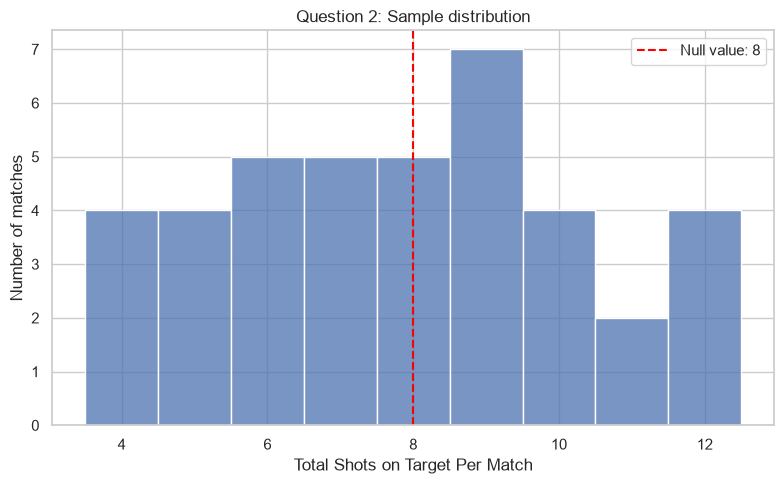

In [13]:
# Start a separate figure for this comparison or distribution.
plt.figure(figsize=(8, 5))
sns.histplot(values, discrete=True)
# Draw the null benchmark as a reference line on the distribution.
plt.axvline(benchmark, color='red', linestyle='--', label='Null value: %g' % benchmark)
plt.title('Question %d: Sample distribution' % NUMBER)
plt.xlabel(variables[-1])
plt.ylabel('Number of matches')
plt.legend()
# Adjust spacing so the title and axis labels fit before saving and displaying.
plt.tight_layout()
plt.savefig(BASE / 'figures' / ('question%d_histogram.png' % NUMBER), dpi=300)
plt.show()

## 12. Save the final result
The analysis is visible above. The following small export block also preserves the summary and sample outputs for submission.

In [14]:
# Export the calculated results for reference; this block performs no additional analysis.
result_text = (
    f"Analytic question: {QUESTION}\nPopulation: {population_description}\n"
    f"Population size: {len(data)}\nSample size: {len(sample)}\n"
    "Sampling: simple random sample of 40 matches without replacement; random_state=42; "
    "Q1 stage groups are formed after sampling; winner/loser pairs remain together.\n\n"
    + summary.to_string() + "\n\n" + ci_table.to_string(index=False)
    + f"\nH0: {h0}\nH1: {h1}\nAlpha: {alpha}\nt-statistic: {t_stat}\np-value: {p_value}"
    + f"\nDecision: {decision}\n{interpretation}\n"
)
(BASE / 'results' / f'question{NUMBER}_results.txt').write_text(result_text)
print(interpretation)
print('Saved sample, population, tables, figures and result text in:', BASE.name)

There is insufficient statistical evidence to conclude that the mean total shots on target per match differs from 8.
Saved sample, population, tables, figures and result text in: Question_2_Shots_On_Target


## Interpretation limits
The supplied file contains 103 matches and omits the third-place match. Its authenticity and extra-time statistical coverage are not independently verified. Recorded match totals are retained even when they exceed half totals. The requested conventional t procedures use no finite-population correction despite sampling a substantial fraction of the eligible data: these are approximate model-based intervals, not exact finite-population intervals. Repeated teams can weaken independence; small samples and skewness can affect accuracy. The four tests use nominal alpha 0.05 without multiplicity adjustment. Associations are not causal effects.